In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict

In [4]:
model = ChatOllama(model="qwen2.5:3b")

In [5]:
class LLMState(TypedDict):
    question: str
    answer: str

In [6]:
def llm_qa(state: LLMState) -> LLMState:
    question = state['question']

    prompt = f'Answer the following question {question}'

    answer = model.invoke(prompt).content

    state['answer'] = answer

    return state

In [10]:
graph = StateGraph(LLMState)

graph.add_node('LLM_QA', llm_qa)

graph.add_edge(START, 'LLM_QA')
graph.add_edge('LLM_QA', END)

workflow = graph.compile()

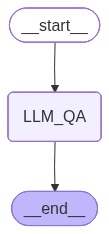

In [11]:
workflow

In [13]:
initial_state = {'question': 'What is black hole?'}

final_answer = workflow.invoke(initial_state)

print(final_answer)

{'question': 'What is black hole?', 'answer': "A black hole is a region of spacetime where gravity is so strong that nothing—no particles or even electromagnetic radiation such as light—can escape from it. This occurs within a certain boundary called the event horizon, beyond which anything and everything is trapped. \n\nBlack holes are thought to form when massive stars collapse at the end of their life cycle. The extreme gravitational pull in these objects can distort spacetime on an enormous scale. Observations suggest that they also play important roles in galactic dynamics, as supermassive black holes are often found at galaxies' centers.\n\nHowever, it's worth noting that our understanding of black holes is based on general relativity and quantum mechanics have not yet been reconciled into a complete theory called quantum gravity. This presents many challenges to our theoretical models of black holes, such as the problem of information loss when matter falls into them (known as t

In [15]:
print(final_answer['answer'])

A black hole is a region of spacetime where gravity is so strong that nothing—no particles or even electromagnetic radiation such as light—can escape from it. This occurs within a certain boundary called the event horizon, beyond which anything and everything is trapped. 

Black holes are thought to form when massive stars collapse at the end of their life cycle. The extreme gravitational pull in these objects can distort spacetime on an enormous scale. Observations suggest that they also play important roles in galactic dynamics, as supermassive black holes are often found at galaxies' centers.

However, it's worth noting that our understanding of black holes is based on general relativity and quantum mechanics have not yet been reconciled into a complete theory called quantum gravity. This presents many challenges to our theoretical models of black holes, such as the problem of information loss when matter falls into them (known as the black hole information paradox).
